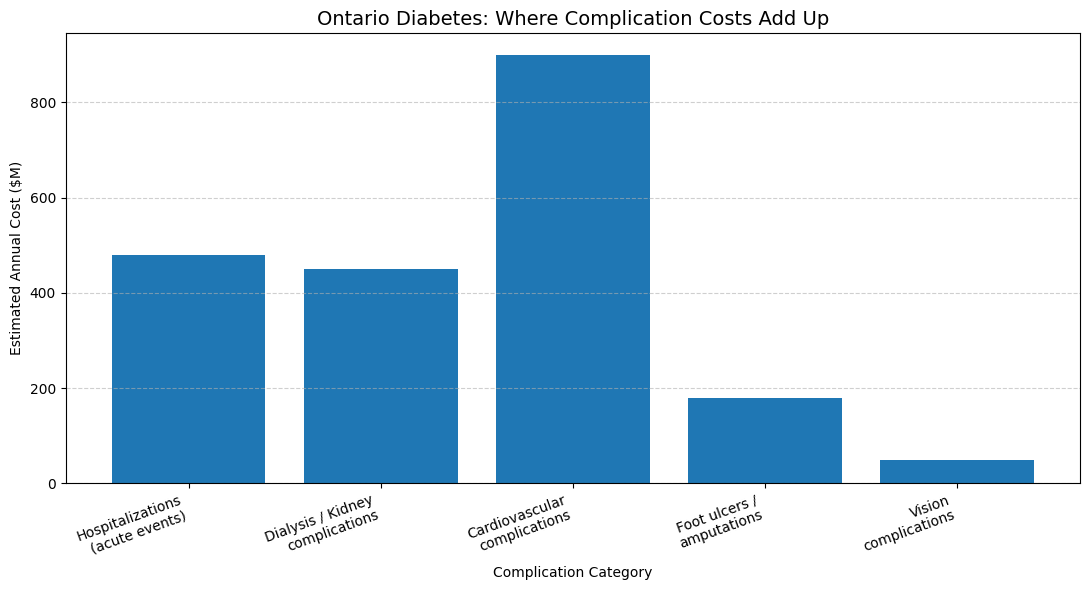

In [1]:
import matplotlib.pyplot as plt

# ==========================================
# Ontario Diabetes: Complications Cost 
# ==========================================
# Units: $ millions per year (illustrative)

complication_cost_millions = {
    "Hospitalizations\n(acute events)": 480,
    "Dialysis / Kidney\ncomplications": 450,
    "Cardiovascular\ncomplications": 900,
    "Foot ulcers /\namputations": 180,
    "Vision\ncomplications": 48
}

# Build bar chart
labels = list(complication_cost_millions.keys())
values = list(complication_cost_millions.values())

plt.figure(figsize=(11, 6))
plt.bar(labels, values)

plt.title("Ontario Diabetes: Where Complication Costs Add Up", fontsize=14)
plt.ylabel("Estimated Annual Cost ($M)")
plt.xlabel("Complication Category")
plt.xticks(rotation=20, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Model AUC (holdout): 0.966
Estimated baseline diabetes risk (Age>=40, dataset proxy): 0.623

=== Ontario 40+ Prevention Model (Annual) ===
Ontario population (40+): 7,800,000
Program uptake: 20% -> participants: 1,560,000
Baseline expected cases (40+): 4,855,839
Cases avoided (annual): 97,117
Baseline cost: $14,567,517,869
Program cost: $93,600,000
Post (after program) total cost: $14,369,767,512
Gross savings (healthcare only): $291,350,357
Net savings (after program cost): $197,750,357
ROI (net_savings / program_cost): 2.11x


C:\Users\h_daw\AppData\Local\Temp\ipykernel_2204\4282388479.py:42: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[symptom_cols] = df[symptom_cols].replace(binary_map)


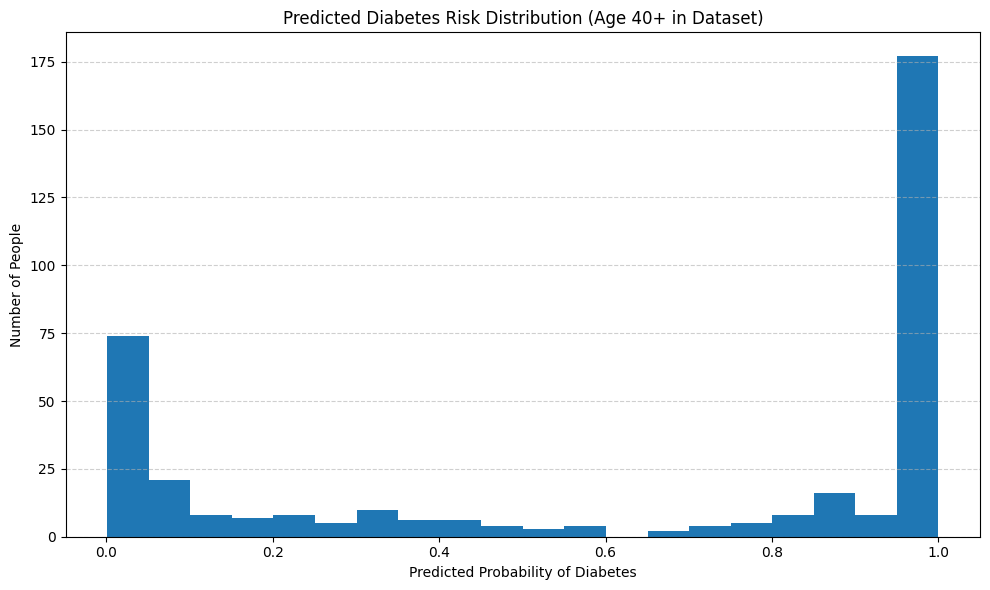

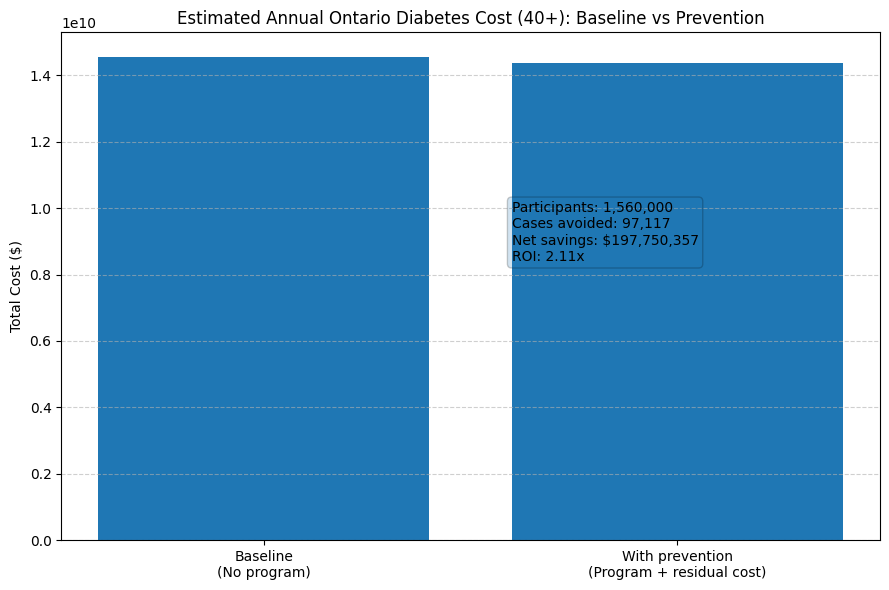

In [ ]:
# ONTARIO COST-SAVINGS CALCULATION (ASSUMPTIONS-BASED) using Risk model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# =========================
# 0) USER INPUTS / ASSUMPTIONS 
# =========================

ONTARIO_POP = 16_300_000
ONTARIO_POP_40_PLUS = 7_800_000          # assumption: ~48% of Ontario population
PROGRAM_UPTAKE = 0.20                    # % of 40+ population reached by education program
RELATIVE_RISK_REDUCTION = 0.10           # 10% relative reduction in diabetes risk among participants

PROGRAM_COST_PER_PERSON = 60             # $ per person reached (education + outreach)
ANNUAL_COST_PER_DIABETES_CASE = 3_000    # $ per year per diabetes case (direct healthcare cost, conservative)
YEARS = 1                                # time horizon (annual)

RANDOM_STATE = 42

# =========================
# 1) LOAD DATA
# =========================
df = pd.read_csv("../03_data/raw/diabetes_data_upload.csv")

# Target
df["class"] = df["class"].map({"Negative": 0, "Positive": 1})

# Encode Gender
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})

# Identify symptom columns (everything except Age, Gender, class)
symptom_cols = [c for c in df.columns if c not in ["Age", "Gender", "class"]]

# Encode Yes/No symptoms
binary_map = {"Yes": 1, "No": 0}
df[symptom_cols] = df[symptom_cols].replace(binary_map)

# Safety: ensure numeric
for c in ["Age", "Gender"] + symptom_cols + ["class"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna()

# =========================
# 2) TRAIN RISK MODEL (Logistic Regression)
# =========================
X = df[["Age", "Gender"] + symptom_cols]
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)
test_probs = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, test_probs)

print(f"Model AUC (holdout): {auc:.3f}")

# =========================
# 3) ESTIMATE RISK FOR 40+ GROUP (from dataset)
# =========================
df_40 = df[df["Age"] >= 40].copy()

# If dataset has few 40+ records, model stability may be lower
if len(df_40) < 30:
    print("Warning: Small sample size for Age>=40 in dataset; results are more assumption-sensitive.")

df_40["pred_risk"] = model.predict_proba(df_40[["Age", "Gender"] + symptom_cols])[:, 1]

# Use the mean predicted risk for 40+ as the Ontario 40+ baseline risk proxy
baseline_risk_40_plus = df_40["pred_risk"].mean()
print(f"Estimated baseline diabetes risk (Age>=40, dataset proxy): {baseline_risk_40_plus:.3f}")

# =========================
# 4) ONTARIO COST-SAVINGS CALCULATION (ASSUMPTIONS-BASED)
# =========================

# Baseline expected cases among Ontario 40+ (proxy using dataset-trained risk)
baseline_cases = ONTARIO_POP_40_PLUS * baseline_risk_40_plus

# People reached by program
participants = ONTARIO_POP_40_PLUS * PROGRAM_UPTAKE

# Cases avoided among participants (relative risk reduction)
cases_avoided = participants * baseline_risk_40_plus * RELATIVE_RISK_REDUCTION

# Costs
baseline_cost = baseline_cases * ANNUAL_COST_PER_DIABETES_CASE * YEARS
program_cost = participants * PROGRAM_COST_PER_PERSON
post_cost = (baseline_cases - cases_avoided) * ANNUAL_COST_PER_DIABETES_CASE * YEARS + program_cost

gross_savings = baseline_cost - (baseline_cases - cases_avoided) * ANNUAL_COST_PER_DIABETES_CASE * YEARS
net_savings = baseline_cost - post_cost
roi = net_savings / program_cost if program_cost > 0 else np.nan

print("\n=== Ontario 40+ Prevention Model (Annual) ===")
print(f"Ontario population (40+): {ONTARIO_POP_40_PLUS:,.0f}")
print(f"Program uptake: {PROGRAM_UPTAKE:.0%} -> participants: {participants:,.0f}")
print(f"Baseline expected cases (40+): {baseline_cases:,.0f}")
print(f"Cases avoided (annual): {cases_avoided:,.0f}")
print(f"Baseline cost: ${baseline_cost:,.0f}")
print(f"Program cost: ${program_cost:,.0f}")
print(f"Post (after program) total cost: ${post_cost:,.0f}")
print(f"Gross savings (healthcare only): ${gross_savings:,.0f}")
print(f"Net savings (after program cost): ${net_savings:,.0f}")
print(f"ROI (net_savings / program_cost): {roi:.2f}x")

# =========================
# 5) VISUAL 1 — Risk Distribution (Age 40+)
# =========================
plt.figure(figsize=(10, 6))
plt.hist(df_40["pred_risk"], bins=20)

plt.title("Predicted Diabetes Risk Distribution (Age 40+ in Dataset)")
plt.xlabel("Predicted Probability of Diabetes")
plt.ylabel("Number of People")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# =========================
# 6) VISUAL 2 — Baseline vs Prevention Total Cost (Ontario 40+)
# =========================
plt.figure(figsize=(9, 6))
labels = ["Baseline\n(No program)", "With prevention\n(Program + residual cost)"]
values = [baseline_cost, post_cost]

plt.bar(labels, values)
plt.title("Estimated Annual Ontario Diabetes Cost (40+): Baseline vs Prevention")
plt.ylabel("Total Cost ($)")
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Add summary text box
summary = (
    f"Participants: {participants:,.0f}\n"
    f"Cases avoided: {cases_avoided:,.0f}\n"
    f"Net savings: ${net_savings:,.0f}\n"
    f"ROI: {roi:.2f}x"
)
plt.gca().text(
    0.55, 0.55, summary,
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(boxstyle="round", alpha=0.2)
)

plt.tight_layout()
plt.show()